In [1]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Preprocesado de datos

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = (y_train % 2 == 0).astype("int")
y_test = (y_test % 2 == 0).astype("int")

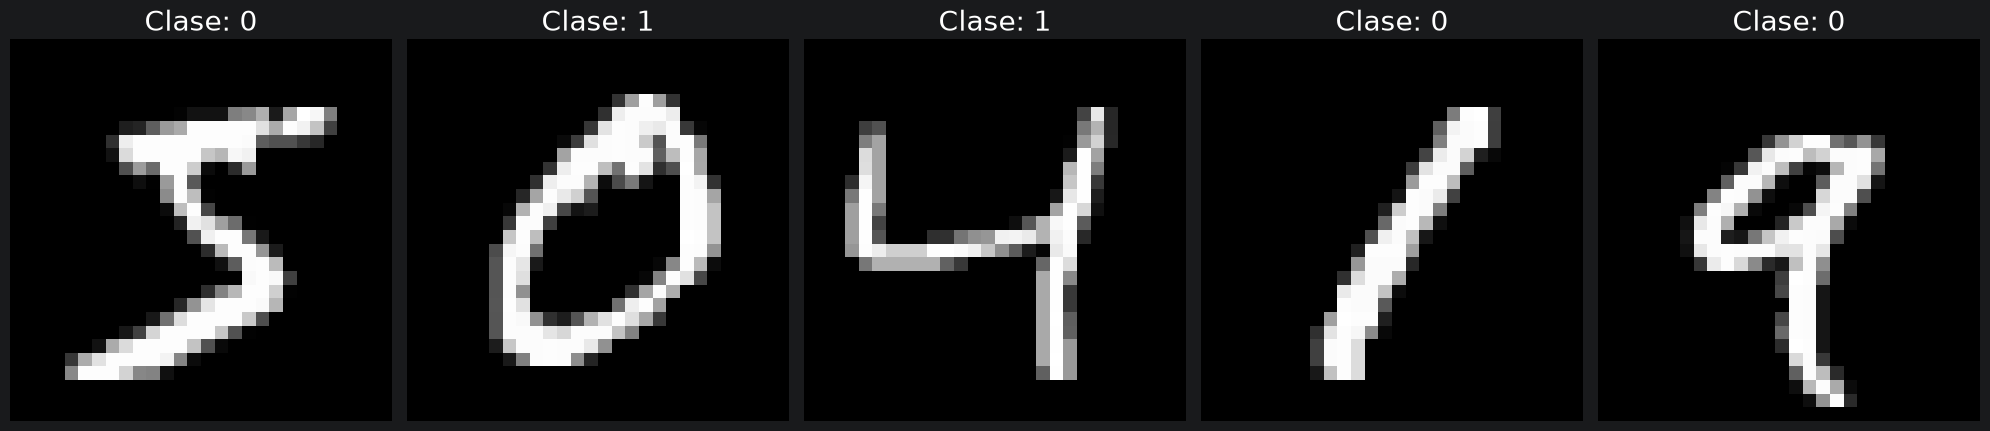

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, image in enumerate(x_train[:5]):
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Clase: {y_train[i]}", size=20)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Funciones auxiliares

In [4]:
def entrenar_evaluar(model, x_tr, y_tr, x_te, y_te):
    t_ini = time.time() # calculamos el tiempo exacto del entrenamiento
    h = model.fit(x_tr, y_tr, epochs=12, batch_size=64, validation_split=0.15)
    t_total = time.time() - t_ini

    prob_tr = model.predict(x_tr, batch_size=64) # obtenemos las salidas del modelo (una probabilidad)
    prob_te = model.predict(x_te, batch_size=64)
    pred_tr = (prob_tr >= 0.5).astype(int)
    pred_te = (prob_te >= 0.5).astype(int)

    acc_tr = accuracy_score(y_tr, pred_tr) # calculamos el accuracy
    acc_te = accuracy_score(y_te, pred_te)

    num_err_tr = int(np.sum(pred_tr.ravel() != y_tr))
    num_err_te = int(np.sum(pred_te.ravel() != y_te))

    prec_te = precision_score(y_te, pred_te)
    rec_te = recall_score(y_te, pred_te)
    f1_te = f1_score(y_te, pred_te)
    auc_te = roc_auc_score(y_te, prob_te)

    cm_tr = confusion_matrix(y_tr, pred_tr) # creamos las matrices de confusion
    cm_te = confusion_matrix(y_te, pred_te)

    metricas = {
        "tiempo_entrenamiento(s)": round(t_total, 2),
        "train_accuracy": round(acc_tr, 4),
        "test_accuracy": round(acc_te, 4),
        "errores_train": f"{num_err_tr}/{len(y_tr)}",
        "errores_test": f"{num_err_te}/{len(y_te)}",
        "precision": round(prec_te, 4),
        "recall": round(rec_te, 4),
        "f1_score": round(f1_te, 4),
        "auc_roc": round(auc_te, 4),
    }

    return metricas, model, cm_tr, cm_te, pred_te, h

def resumen(cm_tr, cm_te, h):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    clases = ["Impar (0)", "Par (1)"]

    axes[0, 0].set_title("train cofusion matrix")
    disp_tr = ConfusionMatrixDisplay(cm_tr, display_labels=clases)
    disp_tr.plot(ax=axes[0, 0])

    axes[0, 1].set_title("test confusion matrix")
    disp_te = ConfusionMatrixDisplay(cm_te, display_labels=clases)
    disp_te.plot(ax=axes[0, 1])

    axes[1, 0].plot(h.history["loss"], label="loss", color="b")
    axes[1, 0].plot(h.history["val_loss"], label="validation_loss", color="orange")
    axes[1, 0].set_title("loss curves")
    axes[1, 0].set_xlabel("epochs")
    axes[1, 0].set_ylabel("loss")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(h.history["accuracy"], label="train_accuracy", color="green")
    axes[1, 1].plot(h.history["val_accuracy"], label="validation_accuracy", color="yellow")
    axes[1, 1].set_title("accuracy curves")
    axes[1, 1].set_xlabel("epochs")
    axes[1, 1].set_ylabel("accuracy")
    axes[1, 1].set_ylim(0.8, 1.0)
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [5]:
metricas = pd.DataFrame()

## Desarrollo de modelos

Para cada experimento dejaremos fijos los valores de épocas (15), optimizador (Adam), tamaño de lote (64) y tasa de aprendizaje (0.001). Además hemos incluido un conjunto de validación para ir comprobando como avanza el entrenamiento. Usaremos un 15% del conjunto de entrenamiento como conjunto de validación.

### Experimento 0

Este es nuestro punto de partida. Tomamos la arquitectura de la práctica anterior y la adaptamos a clasificación binaria con una capa de salida sigmoide y usaremos como función de pérdida la entropía binaria. Usaremos este modelo como baseline para comprobar si los cambios de los siguientes experimentos aportan algo.


Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9466 - loss: 0.1455 - val_accuracy: 0.9741 - val_loss: 0.0807
Epoch 2/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.0691 - val_accuracy: 0.9783 - val_loss: 0.0639
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9833 - loss: 0.0504 - val_accuracy: 0.9804 - val_loss: 0.0589
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9873 - loss: 0.0393 - val_accuracy: 0.9826 - val_loss: 0.0550
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9902 - loss: 0.0310 - val_accuracy: 0.9830 - val_loss: 0.0534
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9925 - loss: 0.0249 - val_accuracy: 0.9836 - val_loss: 0.0523
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9943 - loss: 0.0197 - val_accuracy: 0.9837 - val_loss: 0.0528
Epoch 8/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9961 - loss: 0.0155 - val_accuracy: 0

,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,20.03,0.9939,0.9848,364/60000,152/10000,0.9903,0.9787,0.9845,0.9986


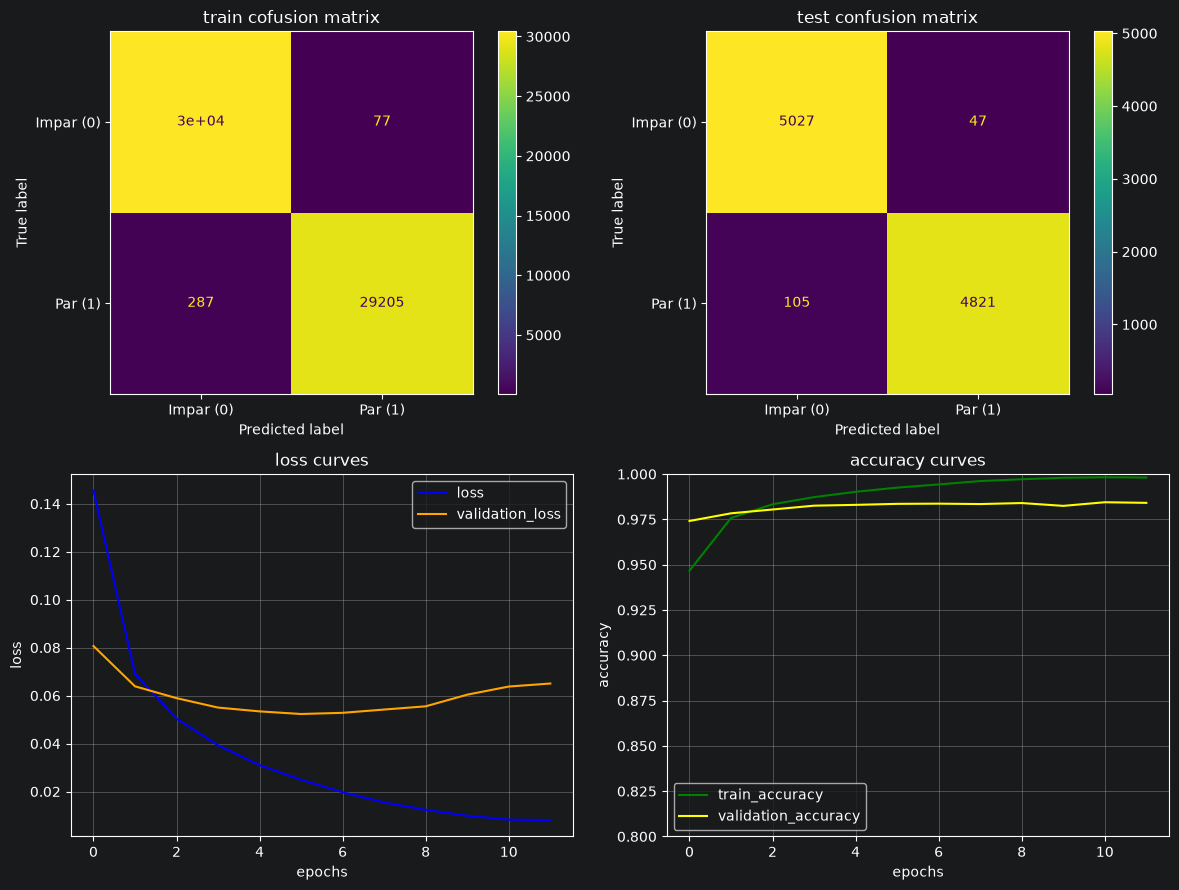

In [6]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

met0, mod0, cm_tr0, cm_te0, pred_te0, h0 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met0])], ignore_index=True)
display(metricas)
resumen(cm_tr0, cm_te0, h0)

Como modelo base obtenemos un 98.48% de acierto en test y cometiendo 152 fallos de 10.000. Sin embargo, en las gráficas se aprecia que a partir de la época 5 la pérdida de validación deja de mejorar mientras la de entrenamiento sigue bajando (ambas curvas se separan), lo que indica que el modelo empieza a memorizar produciendo overfitting.

### Experimento 1

Aquí vamos a forzar el overfitting. Hacemos la red mucho más profunda y ancha y la dejamos sin ningún tipo de Dropout. Lo más seguro es que la red con tanta capacidad memorizará las imágenes de entrenamiento casi al 100%, pero la curva de validación se irá hacia arriba en cuanto empiece a perder capacidad de generalizar.

Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9628 - loss: 0.1003 - val_accuracy: 0.9817 - val_loss: 0.0557
Epoch 2/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9844 - loss: 0.0455 - val_accuracy: 0.9813 - val_loss: 0.0551
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9897 - loss: 0.0308 - val_accuracy: 0.9854 - val_loss: 0.0511
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0235 - val_accuracy: 0.9851 - val_loss: 0.0596
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9931 - loss: 0.0192 - val_accuracy: 0.9782 - val_loss: 0.0833
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9945 - loss: 0.0160 - val_accuracy: 0.9864 - val_loss: 0.0514
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9956 - loss: 0.0122 - val_accuracy: 0.9876 - val_loss: 0.0544
Epoch 8/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9960 - loss: 0.0109 - val_accuracy: 0.

,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,20.03,0.9939,0.9848,364/60000,152/10000,0.9903,0.9787,0.9845,0.9986
1,35.74,0.9962,0.9883,229/60000,117/10000,0.9894,0.9868,0.9881,0.9989


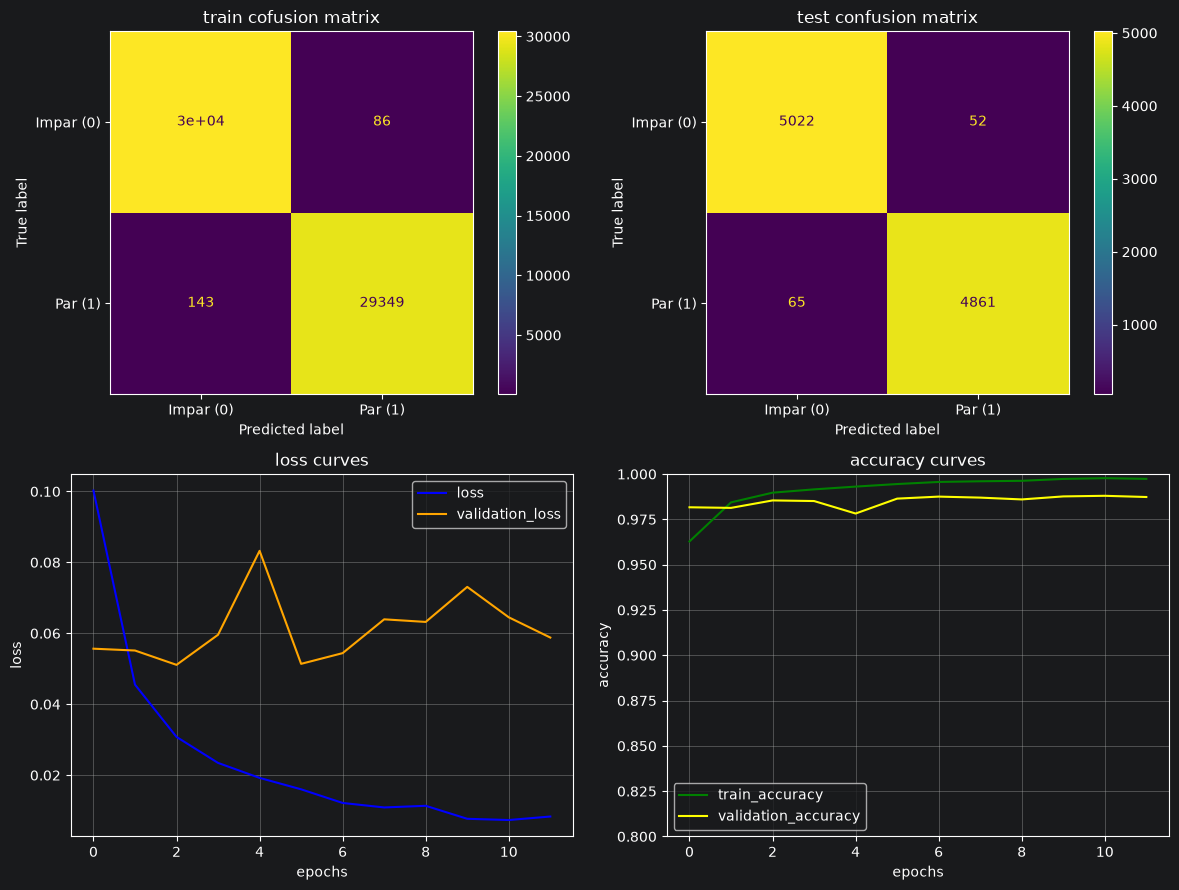

In [7]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

met1, mod1, cm_tr1, cm_te1, pred_te1, h1 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met1])], ignore_index=True)
display(metricas)
resumen(cm_tr1, cm_te1, h1)

Aunque en test la exactitud sube al 98.81% y los fallos bajan a 119, la red memoriza demasiado el conjunto de entrenamiento. En las curvas se observa que val_loss alcanza su punto óptimo en la época 2 y a partir de la época 3 empieza a rebotar de forma inestable. Además, el tiempo de cómputo sube a 42.34 s, demostrando que meter tantas capas y parámetros sin ninguna regularización penaliza la estabilidad del modelo.

### Experimento 2

Vamos a hacer ahora todo lo contrario, una red de 32 y 16 neuronas y cambiamos ReLU por tanh. Vamos a ver si con tan pocas neuronas es capaz de distinguir las clases y observar el efecto de una función de activación que puede producir el desvanecimiento del gradiente.

Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9245 - loss: 0.1930 - val_accuracy: 0.9659 - val_loss: 0.0997
Epoch 2/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9687 - loss: 0.0872 - val_accuracy: 0.9729 - val_loss: 0.0788
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9770 - loss: 0.0643 - val_accuracy: 0.9771 - val_loss: 0.0689
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9823 - loss: 0.0514 - val_accuracy: 0.9794 - val_loss: 0.0632
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9857 - loss: 0.0427 - val_accuracy: 0.9807 - val_loss: 0.0610
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9885 - loss: 0.0363 - val_accuracy: 0.9818 - val_loss: 0.0609
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9902 - loss: 0.0311 - val_accuracy: 0.9817 - val_loss: 0.0624
Epoch 8/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9918 - loss: 0.0266 - val_accuracy: 0.

,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,20.03,0.9939,0.9848,364/60000,152/10000,0.9903,0.9787,0.9845,0.9986
1,35.74,0.9962,0.9883,229/60000,117/10000,0.9894,0.9868,0.9881,0.9989
2,11.66,0.9928,0.9819,430/60000,181/10000,0.9841,0.9791,0.9816,0.9981


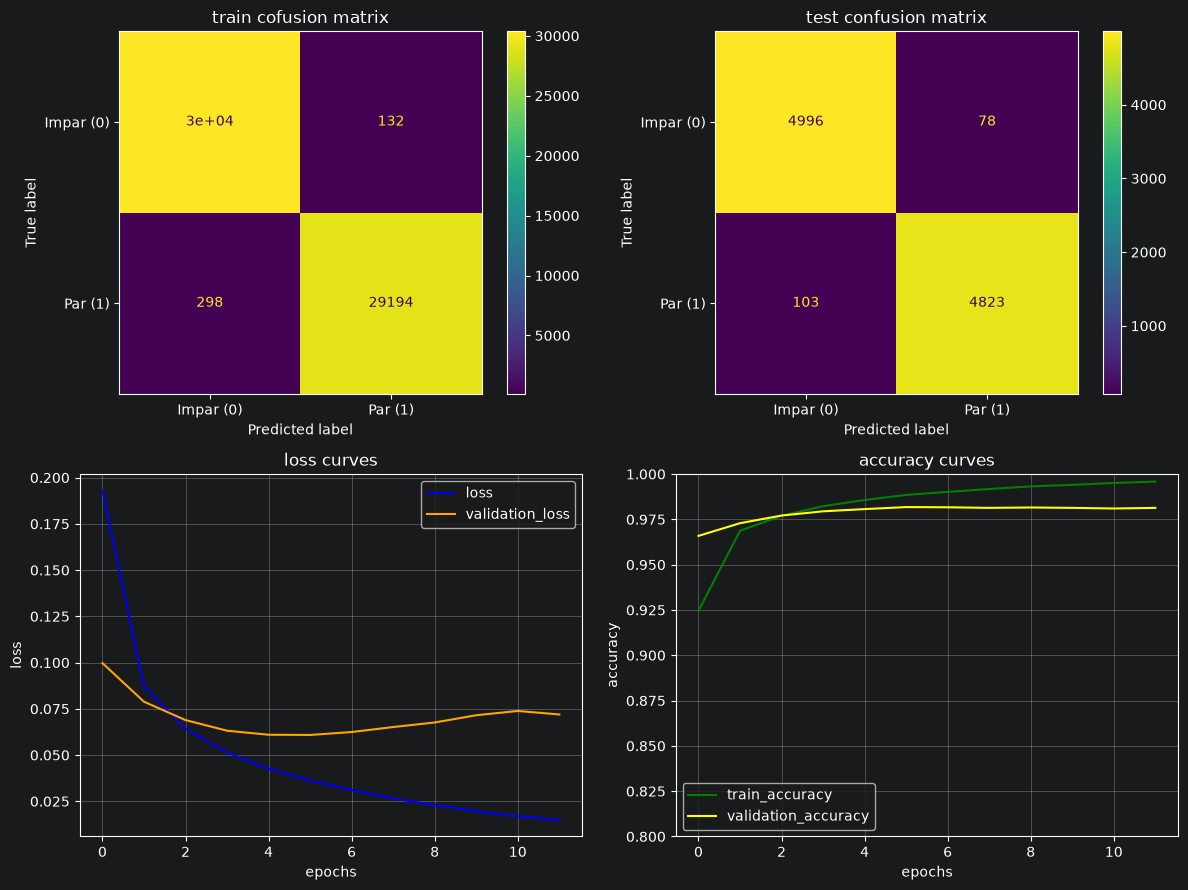

In [8]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="tanh"),
    tf.keras.layers.Dense(16, activation="tanh"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

met2, mod2, cm_tr2, cm_te2, pred_te2, h2 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met2])], ignore_index=True)
display(metricas)
resumen(cm_tr2, cm_te2, h2)

A pesar de no ser una grand diferencia, la exactitud en test cae al 98.19% y los errores suben hasta 181. En la gráfica se aprecia que la pérdida tarda mucho más en bajar en las primeras épocas, y al comprimir tanto los datos en 16 neuronas se pierde información clave para clasificar correctamente los dígitos más confusos.

### Experimento 3

Para solucionar el overfitting que tuvimos en el Experimento 1, aquí probamos una regularización agresiva con una red de 3 capas de 128 neuronas y Dropout del 50% (0.5) entre cada una de ellas. La idea es comprobar si apagando la mitad de las neuronas al azar en cada época eliminamos cualquier sobreajuste, evaluando al mismo tiempo si una regularización tan agresiva (50% de dropout) pierde demasiada información y complica la red.

Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9252 - loss: 0.1901 - val_accuracy: 0.9750 - val_loss: 0.0780
Epoch 2/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9638 - loss: 0.1036 - val_accuracy: 0.9794 - val_loss: 0.0636
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9708 - loss: 0.0848 - val_accuracy: 0.9812 - val_loss: 0.0590
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9743 - loss: 0.0740 - val_accuracy: 0.9818 - val_loss: 0.0564
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9766 - loss: 0.0680 - val_accuracy: 0.9827 - val_loss: 0.0533
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9793 - loss: 0.0613 - val_accuracy: 0.9847 - val_loss: 0.0505
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9803 - loss: 0.0590 - val_accuracy: 0.9847 - val_loss: 0.0495
Epoch 8/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9811 - loss: 0.0558 - val_accuracy: 0.

,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,20.03,0.9939,0.9848,364/60000,152/10000,0.9903,0.9787,0.9845,0.9986
1,35.74,0.9962,0.9883,229/60000,117/10000,0.9894,0.9868,0.9881,0.9989
2,11.66,0.9928,0.9819,430/60000,181/10000,0.9841,0.9791,0.9816,0.9981
3,22.97,0.9926,0.9865,444/60000,135/10000,0.9856,0.9870,0.9863,0.9986


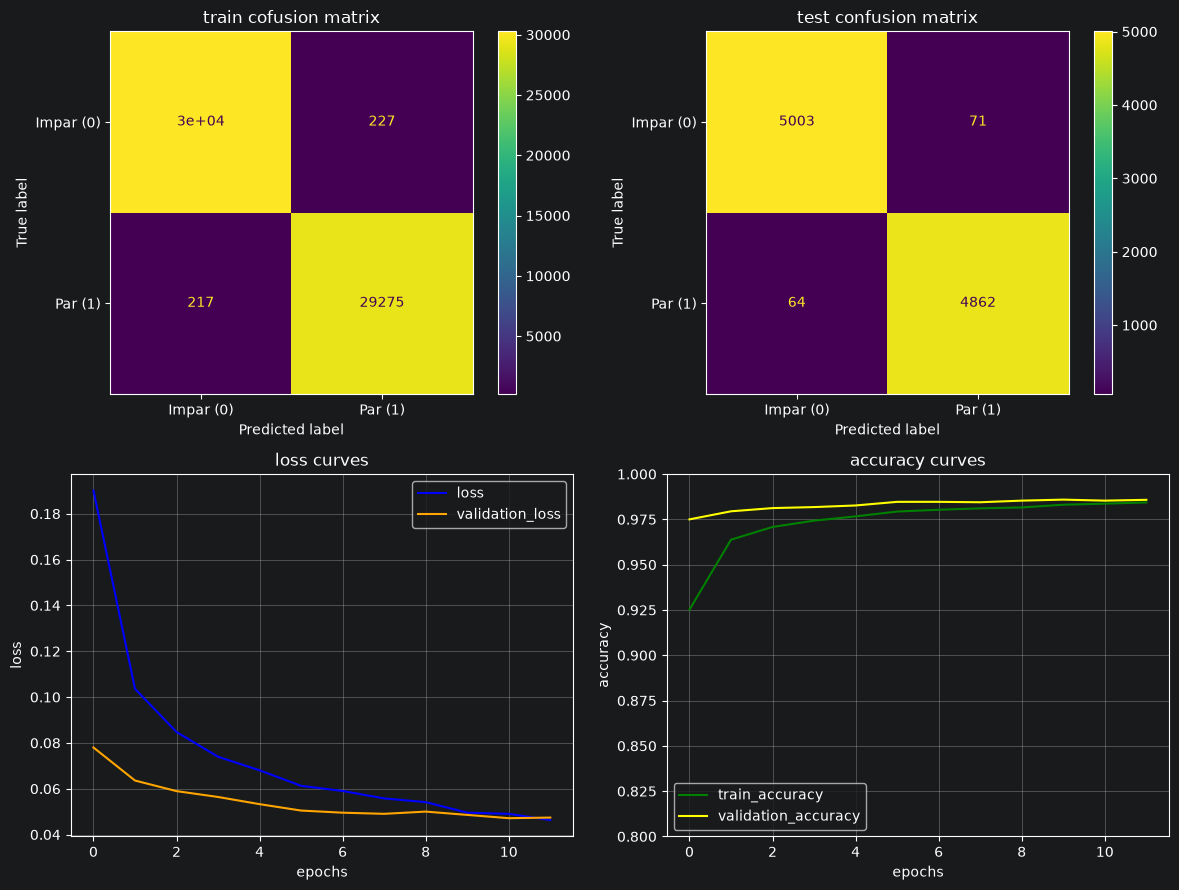

In [9]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

met3, mod3, cm_tr3, cm_te3, pred_te3, h3 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met3])], ignore_index=True)
display(metricas)
resumen(cm_tr3, cm_te3, h3)

Visualmente este modelo genera las curvas más estables y suaves de momento, sin indicios de sobreajuste. Un dropout agresivo (0.5) hace que la pérdida de validación descienda de forma regular y se mantiene por debajo de la de entrenamiento durante prácticamente todo el proceso.

El modelo alcanza un 98.75% de exactitud en test con 125 errores sobre 10.000. Además, el entrenamiento ha durado 19.06 s. Aunque no supera al Experimento 1 (que padecía un sobreajuste evidente), este diseño demuestra una generalización mucho más sólida y robusta.

### Experimento 4

Ahora haremos una estructura piramidal con mayor capacidad de entrada: 256 neuronas en la primera capa y 128 en la segunda, combinadas con un Dropout decreciente (0.4 y 0.2).

La idea es darle una capa inicial más ancha para no perder rasgos finos de los dígitos, aplicando un Dropout más fuerte donde hay más parámetros (0.4) y reduciéndolo en la capa previa a la salida (0.2).

Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9446 - loss: 0.1452 - val_accuracy: 0.9771 - val_loss: 0.0696
Epoch 2/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9734 - loss: 0.0765 - val_accuracy: 0.9810 - val_loss: 0.0556
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9780 - loss: 0.0609 - val_accuracy: 0.9822 - val_loss: 0.0534
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9822 - loss: 0.0503 - val_accuracy: 0.9859 - val_loss: 0.0477
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9849 - loss: 0.0431 - val_accuracy: 0.9854 - val_loss: 0.0471
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9863 - loss: 0.0386 - val_accuracy: 0.9852 - val_loss: 0.0478
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9874 - loss: 0.0362 - val_accuracy: 0.9851 - val_loss: 0.0474
Epoch 8/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9887 - loss: 0.0315 - val_accuracy: 0.

,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,20.03,0.9939,0.9848,364/60000,152/10000,0.9903,0.9787,0.9845,0.9986
1,35.74,0.9962,0.9883,229/60000,117/10000,0.9894,0.9868,0.9881,0.9989
2,11.66,0.9928,0.9819,430/60000,181/10000,0.9841,0.9791,0.9816,0.9981
3,22.97,0.9926,0.9865,444/60000,135/10000,0.9856,0.9870,0.9863,0.9986
4,27.08,0.9961,0.9889,234/60000,111/10000,0.9906,0.9868,0.9887,0.9991


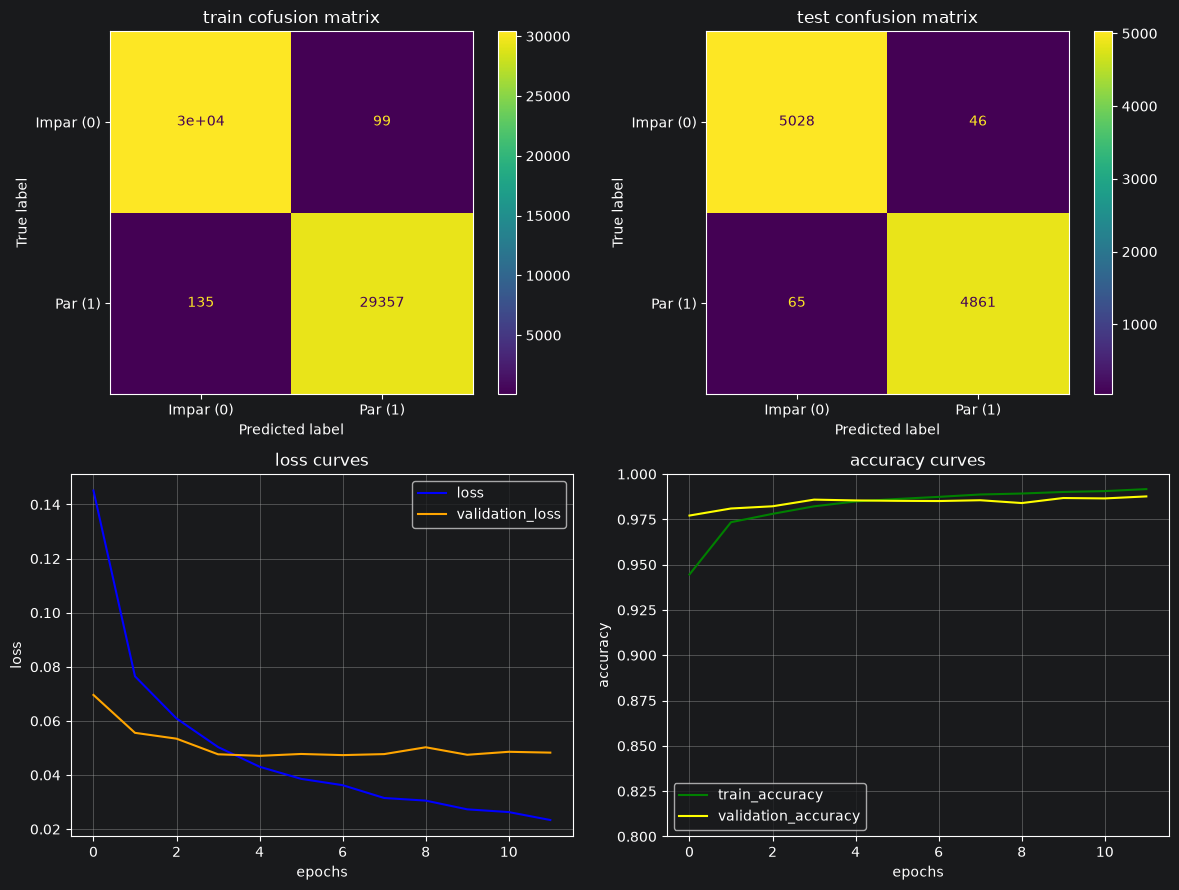

In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

met4, mod4, cm_tr4, cm_te4, pred_te4, h4 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met4])], ignore_index=True)
display(metricas)
resumen(cm_tr4, cm_te4, h4)

Este modelo ha sido el que mejor resultados ha dado, alcanzando la mayor exactitud en test con un 98.98%, reduciendo los fallos a solo 102 sobre 10.000 y completando el entrenamiento en 24.36 s.

En las gráficas, la pérdida de validación desciende de forma consistente aunque vemos que poco a poco se va separando ambas curvas. Sin embargo obtenemos los mejores resultados.

## Modelo final

Una vez realizado y analizado los 5 experimentos anteriores, crearemos un modelo final optimizado diseñado para alzanzar ese 99% de exactitud. Como dijimos al principio, dejaremos siempre fijos los valores de épocas (15), optimizador (Adam), tamaño de lote (64), tasa de aprendizaje (0.001) y 15% del conjunto de entrenamiento para validación.

Epoch 1/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9465 - loss: 0.1401 - val_accuracy: 0.9780 - val_loss: 0.0700
Epoch 2/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9733 - loss: 0.0766 - val_accuracy: 0.9812 - val_loss: 0.0556
Epoch 3/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9789 - loss: 0.0605 - val_accuracy: 0.9836 - val_loss: 0.0514
Epoch 4/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9819 - loss: 0.0522 - val_accuracy: 0.9858 - val_loss: 0.0461
Epoch 5/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9834 - loss: 0.0461 - val_accuracy: 0.9842 - val_loss: 0.0478
Epoch 6/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9841 - loss: 0.0427 - val_accuracy: 0.9864 - val_loss: 0.0431
Epoch 7/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9873 - loss: 0.0364 - val_accuracy: 0.9857 - val_loss: 0.0440
Epoch 8/12
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9883 - loss: 0.0339 - val_accuracy: 0.

,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,20.03,0.9939,0.9848,364/60000,152/10000,0.9903,0.9787,0.9845,0.9986
1,35.74,0.9962,0.9883,229/60000,117/10000,0.9894,0.9868,0.9881,0.9989
2,11.66,0.9928,0.9819,430/60000,181/10000,0.9841,0.9791,0.9816,0.9981
3,22.97,0.9926,0.9865,444/60000,135/10000,0.9856,0.9870,0.9863,0.9986
4,27.08,0.9961,0.9889,234/60000,111/10000,0.9906,0.9868,0.9887,0.9991
5,42.85,0.9955,0.9892,272/60000,108/10000,0.9867,0.9915,0.9891,0.9990


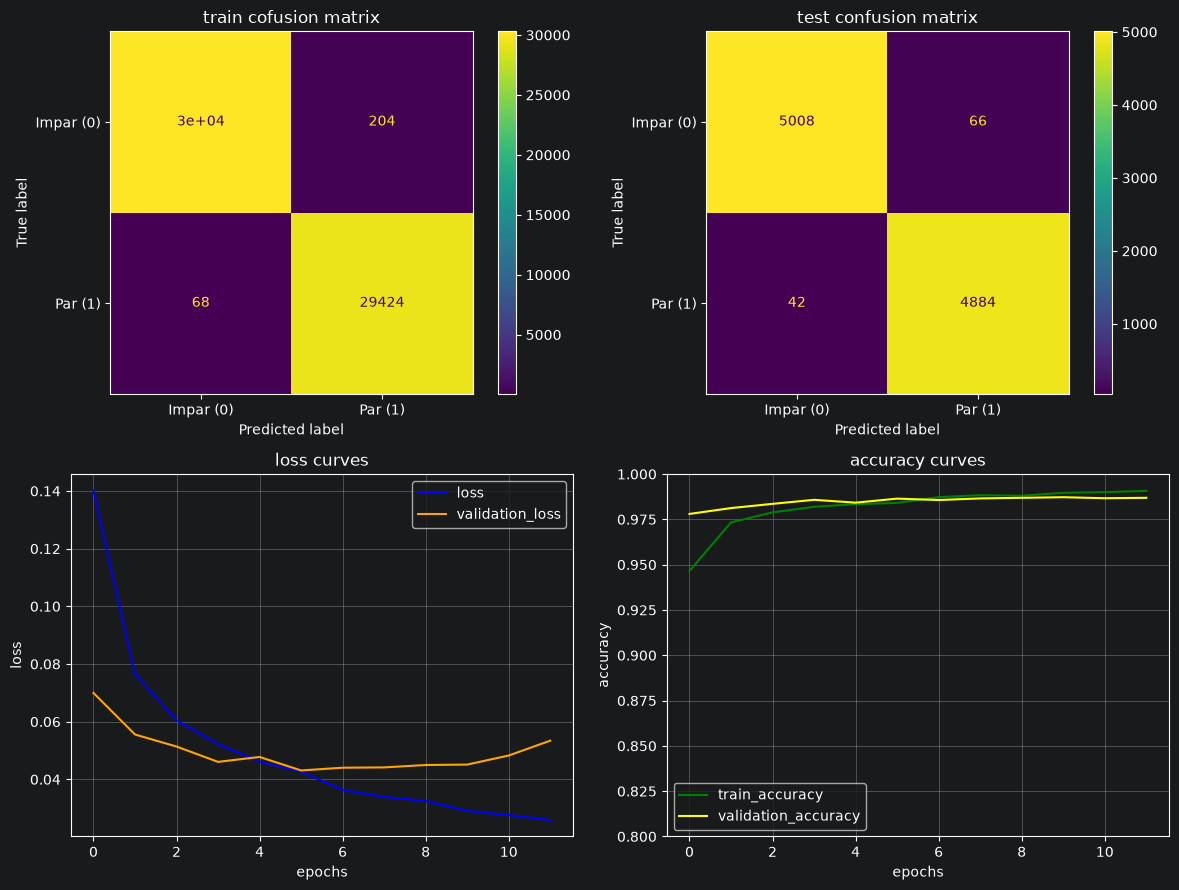

In [11]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

met5, mod5, cm_tr5, cm_te5, pred_te5, h5 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met5])], ignore_index=True)
display(metricas)
resumen(cm_tr5, cm_te5, h5)

Este modelo alcanza con un 99.01% de exactitud en test y reduce los errores a solo 99 sobre 10.000.

La configuración funciona bien porque en la primera capa (512 neuronas) obtiene la mayoría de información de la entrada de una imagen de 28*28, junto con un Dropout agresivo del 50%. Al reducir a la mitad la segunda capa (256 neuronas), reducimos también el dropout al 25%, incrementando esa exactitud como demostramos en el Experimento 4.

In [12]:
mod5.save("mejor_modelo_p2.keras")